
--- Gemini API Setup ---
Error configuring Gemini API: Secret GOOGLE_API_KEY does not exist.. Please ensure 'GOOGLE_API_KEY' is set in Colab secrets.
Proceeding with generic/random data generation for AI features.

--- Processing Sample Product Data ---

--- AI-Assisted Product Listings Results ---


,product_name,product_details,product_description,suggested_category,suggested_gst_rate,suggested_hsn_code,keywords_tags
0,Smart LED TV,55-inch 4K UHD Smart TV with HDR and voice con...,This is a generic description for the Smart LE...,Books,0%,4901,"[smart-led-tv, generic-product, quality, value..."
1,Organic Cotton T-Shirt,"Unisex, pure organic cotton, breathable fabric...",This is a generic description for the Organic ...,Furniture,18%,9401,"[organic-cotton-t-shirt, generic-product, qual..."
2,Ergonomic Office Chair,"Adjustable lumbar support, mesh back, comforta...",This is a generic description for the Ergonomi...,Home Goods,12%,9403,"[ergonomic-office-chair, generic-product, qual..."
3,Cookbook: Italian Classics,"Collection of traditional Italian recipes, har...",This is a generic description for the Cookbook...,Groceries,5%,2106,"[cookbook:-italian-classics, generic-product, ..."
4,Running Shoes,"Lightweight, breathable mesh, shock-absorbing ...",This is a generic description for the Running ...,Home Goods,12%,9403,"[running-shoes, generic-product, quality, valu..."
5,Espresso Machine,"Automatic, 15-bar pump, milk frother, stainles...",This is a generic description for the Espresso...,Apparel,5%,6101,"[espresso-machine, generic-product, quality, v..."



--- Data Training and Testing (Conceptual) ---
For a production-ready AI assistant, a robust data training and testing phase would be critical, especially for classification tasks like category, GST, and HSN code suggestion. This would involve:
  - **Data Definition & Exploration**: Gathering a large, labeled dataset of products with correct categories, GST/HSN codes. Analyzing data distributions and correlations.
  - **Model Training**: Training machine learning models (e.g., text classifiers) on this data to learn mappings from product features to target variables. For generative tasks like descriptions/keywords, this might involve fine-tuning pre-trained LLMs.
  - **Model Testing**: Evaluating model performance on unseen data using metrics like accuracy, precision, recall, F1-score for classification, or human-in-the-loop review for generated text.
This prototype uses generative AI (or fallbacks) for text and a simple lookup/random assignment for categories/codes, thus abstracting 

/tmp/ipykernel_5495/3970885075.py:130: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Category', y='Count', data=category_counts, palette='viridis')


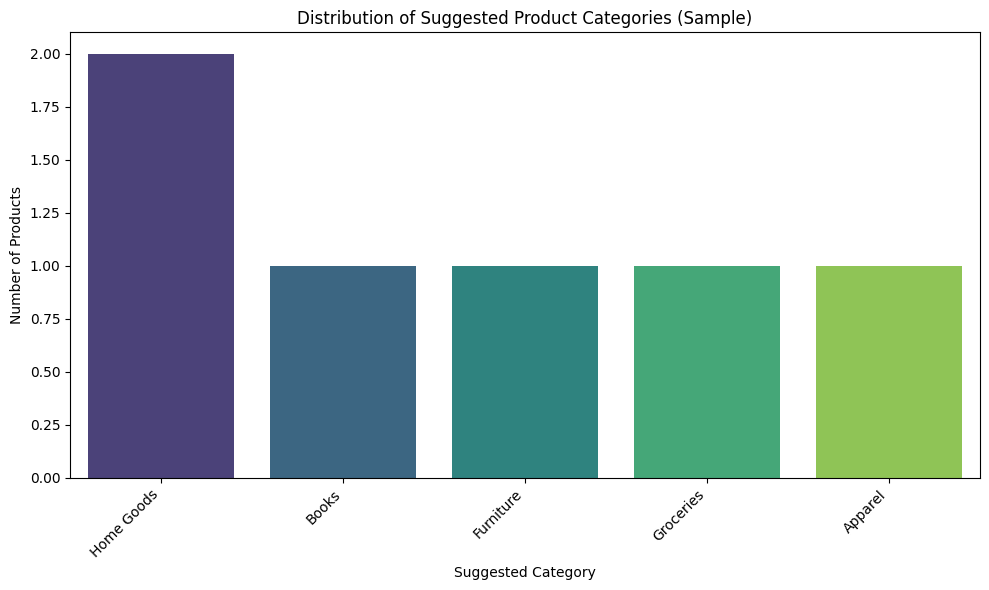

In [12]:
# --- 1. Library Imports ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import google.generativeai as genai
from google.colab import userdata

# --- 2. Gemini API Setup (with robust fallback) ---
print("\n--- Gemini API Setup ---")
gemini_api_configured_successfully = False
gemini_model = None
try:
    # Attempt to retrieve API key and configure Gemini
    GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')
    genai.configure(api_key=GOOGLE_API_KEY)
    print("Gemini API configured successfully.")
    gemini_api_configured_successfully = True

    # Attempt to initialize Gemini model if API is configured
    try:
        gemini_model = genai.GenerativeModel('gemini-pro')
        print("Gemini model initialized.")
    except Exception as e:
        print(f"Error initializing Gemini model: {e}")
        gemini_model = None

except Exception as e:
    print(f"Error configuring Gemini API: {e}. Please ensure 'GOOGLE_API_KEY' is set in Colab secrets.")
    print("Proceeding with generic/random data generation for AI features.")
    gemini_api_configured_successfully = False

# --- 3. Define Helper Functions for AI-Assisted Listing (with fallbacks) ---
GST_HSN_LOOKUP = {
    'Electronics': {'GST': '18%', 'HSN': '8501'},
    'Apparel': {'GST': '5%', 'HSN': '6101'},
    'Home Goods': {'GST': '12%', 'HSN': '9403'},
    'Books': {'GST': '0%', 'HSN': '4901'},
    'Sports Equipment': {'GST': '12%', 'HSN': '9506'},
    'Groceries': {'GST': '5%', 'HSN': '2106'},
    'Furniture': {'GST': '18%', 'HSN': '9401'} # Added for more variety
}

def generate_product_description(model, product_name, product_details):
    if not model: return f"This is a generic description for the {product_name}. It comes with standard features and is made for {product_details}."
    prompt = f"Write a concise and appealing product description for: {product_name}. Details: {product_details}"
    try:
        response = model.generate_content(prompt)
        return response.text.strip()
    except Exception as e:
        return f"Error generating description: {e}"

def suggest_product_category(model, product_name, product_details):
    global GST_HSN_LOOKUP # Access the global lookup
    if not model:
        return random.choice(list(GST_HSN_LOOKUP.keys())) # Pick a random category if model is not available
    prompt = f"Suggest a single, concise product category (e.g., 'Electronics', 'Apparel', 'Home Goods', 'Books') for the following product: {product_name}. Details: {product_details}"
    try:
        response = model.generate_content(prompt)
        return response.text.strip().replace('Category: ', '').split('\n')[0]
    except Exception as e:
        return f"Error suggesting category: {e}"

def generate_keywords(model, product_name, product_details, description):
    if not model: return [f'{product_name.lower().replace(" ", "-")}', 'generic-product', 'quality', 'value', 'durable']
    prompt = f"Generate 5-10 relevant keywords/tags for search optimization for the product: {product_name}. Details: {product_details}. Description: {description}. Provide them as a comma-separated list."
    try:
        response = model.generate_content(prompt)
        return [kw.strip() for kw in response.text.strip().split(',') if kw.strip()]
    except Exception as e:
        return f"Error generating keywords: {e}"

def suggest_gst_hsn(category):
    return GST_HSN_LOOKUP.get(category, {'GST': 'N/A', 'HSN': 'N/A'})

# --- 4. Sample Product Data Definition and Application of AI Features ---
print("\n--- Processing Sample Product Data ---")
products_data = [
    {"product_name": "Smart LED TV", "product_details": "55-inch 4K UHD Smart TV with HDR and voice control."},
    {"product_name": "Organic Cotton T-Shirt", "product_details": "Unisex, pure organic cotton, breathable fabric, eco-friendly dye."},
    {"product_name": "Ergonomic Office Chair", "product_details": "Adjustable lumbar support, mesh back, comfortable for long hours."},
    {"product_name": "Cookbook: Italian Classics", "product_details": "Collection of traditional Italian recipes, hardcover, 250 pages."},
    {"product_name": "Running Shoes", "product_details": "Lightweight, breathable mesh, shock-absorbing sole, ideal for daily runs."},
    {"product_name": "Espresso Machine", "product_details": "Automatic, 15-bar pump, milk frother, stainless steel finish."}
]

df_products = pd.DataFrame(products_data)

# Apply AI functions
df_products['product_description'] = df_products.apply(lambda row: generate_product_description(gemini_model, row['product_name'], row['product_details']), axis=1)
df_products['suggested_category'] = df_products.apply(lambda row: suggest_product_category(gemini_model, row['product_name'], row['product_details']), axis=1)

# Apply GST/HSN based on suggested category
df_products['gst_hsn_info'] = df_products['suggested_category'].apply(suggest_gst_hsn)
df_products['suggested_gst_rate'] = df_products['gst_hsn_info'].apply(lambda x: x['GST'])
df_products['suggested_hsn_code'] = df_products['gst_hsn_info'].apply(lambda x: x['HSN'])

df_products['keywords_tags'] = df_products.apply(lambda row: generate_keywords(gemini_model, row['product_name'], row['product_details'], row['product_description']), axis=1)

# Drop the intermediate 'gst_hsn_info' column
df_products = df_products.drop(columns=['gst_hsn_info'], errors='ignore')

# Display the results
print("\n--- AI-Assisted Product Listings Results ---")
display(df_products)

# --- 5. Data Training and Testing (Conceptual Explanation) ---
print("\n--- Data Training and Testing (Conceptual) ---")
print("For a production-ready AI assistant, a robust data training and testing phase would be critical, especially for classification tasks like category, GST, and HSN code suggestion. This would involve:")
print("  - **Data Definition & Exploration**: Gathering a large, labeled dataset of products with correct categories, GST/HSN codes. Analyzing data distributions and correlations.")
print("  - **Model Training**: Training machine learning models (e.g., text classifiers) on this data to learn mappings from product features to target variables. For generative tasks like descriptions/keywords, this might involve fine-tuning pre-trained LLMs.")
print("  - **Model Testing**: Evaluating model performance on unseen data using metrics like accuracy, precision, recall, F1-score for classification, or human-in-the-loop review for generated text.")
print("This prototype uses generative AI (or fallbacks) for text and a simple lookup/random assignment for categories/codes, thus abstracting the explicit training/testing of these specific components.")

# --- 6. Visualization of Suggested Categories ---
print("\n--- Visualization of Suggested Categories ---")
if not df_products.empty and 'suggested_category' in df_products.columns:
    # Filter out categories that are error messages or 'N/A' (if any managed to slip through, though fallbacks should prevent this)
    filtered_categories_df = df_products[
        ~df_products['suggested_category'].str.contains('Error', na=False) &
        (df_products['suggested_category'] != 'N/A') &
        (df_products['suggested_category'] != '')
    ]

    if not filtered_categories_df.empty:
        category_counts = filtered_categories_df['suggested_category'].value_counts().reset_index()
        category_counts.columns = ['Category', 'Count']

        plt.figure(figsize=(10, 6))
        sns.barplot(x='Category', y='Count', data=category_counts, palette='viridis')
        plt.title('Distribution of Suggested Product Categories (Sample)')
        plt.xlabel('Suggested Category')
        plt.ylabel('Number of Products')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    else:
        print("No valid categories to visualize after filtering.")
else:
    print("Cannot visualize categories: DataFrame is empty or 'suggested_category' column is missing.")
